# Analise de Dados - Campanha Nacional de Vacinação contra Covid-19
**Professor: Luis Cuevas**  
**Aluna: Aline Daffiny Ferreira Gomes**

## Dataset
- **Nome**: Campanha Nacional de Vacinação contra Covid-19
- **Órgão responsável**: Ministério da Saúde
- **Tamanho (Linhas x Colunas)**: 2.160.888×32  
  Por se tratar de um conjunto de dados muito grande, foi escolhido somente um csv para a análise, o "Dados AM - Parte 1"  
- **Descrição**:  
  Esta página tem como finalidade disponibilizar os registros de vacinação contra Covid-19, sem identificação do cidadão (anonimizados), contidos na Rede Nacional de Dados em Saúde (RNDS), desde o início da Campanha. São dados disponibilizados pela SI-PNI, e-SUS APS e dos sistemas próprios de estados e municípios que estão devidamente integrados com a RNDS. Os dados disponíveis no OpenDatasus englobam o número de doses aplicadas, por UF e municípios, por um determinado período, por gênero, por faixa etária e por tipo de vacina. Consta ainda com o percentual de vacinados, as coberturas vacinais (CV) do Brasil, das UF e dos municípios, CV em um determinado período, por gênero, por faixa etária e o mapa de distribuição espacial das coberturas vacinais segundo as UF e municípios.


### Descrição das variáveis
- document_id: identificação do documento
- paciente_id: identificação do paciente
- paciente_idade: (int) idade do paciente;
- paciente_dataNascimento (data, yyyy/mm/dd) data de nascimento do paciente;
- paciente_enumSexoBiologico: (categórica binária, M/F) sexo biológico do paciente;
- paciente_racaCor_codigo: (categórica) representa numéricamente um valor de raça;
- paciente_racaCor_valor: (categórica nominal, BRANCA/PARDA/PRETA/AMARELA/INDIGENA/SEM INFORMAÇÃO) raça do paciente;
- paciente_endereco_coIbgeMunicipio: (categórica nominal) código do munícipio onde o paciente reside
- paciente_endereco_coPais: (categórica nominal) código do país de origem do paciente
- paciente_endereco_nmMunicipio: (categórica nominal) nome do munícipio onde o paciente reside
- paciente_endereco_nmPais: (categórica nominal) nome do país de origem do paciente
- paciente_endereco_uf: (categórica nominal) sigla da unidade federativa de origem do paciente
- paciente_endereco_cep: (categórica nominal) número de CEP do paciente
- paciente_nacionalidade_enumNacionalidade: (categórica nominal, B/E/N) representação codificada da nacionalidade do paciente
- estabelecimento_valor: ?
- estabelecimento_razaoSocial: (categórica nominal) nome da organização responsável
- estalecimento_noFantasia: (categórica nomainal) nome do estabelecimento responsável
- estabelecimento_municipio_codigo: (categórica nominal) código do munícipio do estabelecimento
- estabelecimento_municipio_nome: (categórica nominal) nome do munícipio do estabelecimento
- estabelecimento_uf: (categórica nominal) sigla da unidade federativa do estabelecimento
- vacina_grupoAtendimento_codigo: (categórica nominal) código do grupo de atendimento
- vacina_grupoAtendimento_nome: (categórica nominal) nome do grupo de atendimento
- vacina_categoria_codigo: (categórica nominal) código da categoria para qual a vacina se destina
- vacina_categoria_nome: (categórica nominal) nome da categoria para qual a vacina se destina
- vacina_lote: (categórica nominal) identificação do lote da vacina
- vacina_fabricante_nome: (categórica nominal) empresa fabricante da vacina
- vacina_fabricante_referencia: (categórica nominal) código da empresa fabricante da vacina
- vacina_dataAplicacao: (data, yyyy/mm/dd) data de aplicação da vacina
- vacina_descricao_dose: (categórica ordinal) qual a dose sendo aplicada
- vacina_codigo: ?
- vacina_nome: (categórica nominal) identificação completa da vacina sendo aplicada
- sistema_origem: (categórica nominal) sistema de origem do registro

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Atribuindo o dataset sendo utilizado
path = "amazonas_pt1.csv"
data = pd.read_csv(path, sep=';')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160888 entries, 0 to 2160887
Data columns (total 32 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   document_id                               object 
 1   paciente_id                               object 
 2   paciente_idade                            float64
 3   paciente_dataNascimento                   object 
 4   paciente_enumSexoBiologico                object 
 5   paciente_racaCor_codigo                   float64
 6   paciente_racaCor_valor                    object 
 7   paciente_endereco_coIbgeMunicipio         float64
 8   paciente_endereco_coPais                  float64
 9   paciente_endereco_nmMunicipio             object 
 10  paciente_endereco_nmPais                  object 
 11  paciente_endereco_uf                      object 
 12  paciente_endereco_cep                     float64
 13  paciente_nacionalidade_enumNacionalidade  object 
 14  es

In [5]:
data.head(5)

,document_id,paciente_id,paciente_idade,paciente_dataNascimento,paciente_enumSexoBiologico,paciente_racaCor_codigo,paciente_racaCor_valor,paciente_endereco_coIbgeMunicipio,paciente_endereco_coPais,paciente_endereco_nmMunicipio,...,vacina_categoria_codigo,vacina_categoria_nome,vacina_lote,vacina_fabricante_nome,vacina_fabricante_referencia,vacina_dataAplicacao,vacina_descricao_dose,vacina_codigo,vacina_nome,sistema_origem
0,90cb6be0-12d5-4314-8673-c89cc608669b-i0b0,18f63e6002a16fb9ac83e03c5733f95c5902087c8e8160...,34.0,1986-11-15,M,4.0,AMARELA,130240.0,10.0,LABREA,...,2.0,Faixa Etária,213VCD027Z,ASTRAZENECA/FIOCRUZ,Organization/33781055000135,2021-06-16,1ª Dose,85,COVID-19 ASTRAZENECA/FIOCRUZ - COVISHIELD,Novo PNI
1,4439d386-6c44-4a91-a3ef-e578a34a5db9-i0b0,13e39ca0a8601d582b495bf451e35a863b4f8f17fb9d8b...,4.0,2019-09-01,M,3.0,PARDA,130170.0,10.0,HUMAITA,...,2.0,Faixa Etária,230052,BUTANTAN,152,2024-02-23,Única,33,INF3,Novo PNI
2,90cce81d-4595-4a2a-bba9-96290bedbd1f-i0b0,f003b15c885469807dcfb03f6bacfa50b2df5de5516e5f...,27.0,1995-05-29,M,3.0,PARDA,130260.0,10.0,MANAUS,...,2.0,Faixa Etária,FM2951,PFIZER,NaN,2022-06-10,3ª Dose,87,COVID-19 PFIZER - COMIRNATY,SMV
3,443c9538-a986-403c-8e4f-cbb4ef25d909-i0b0,1b9e5dc6b34ab3cda0a5f7215267064c3aba286900a5cb...,44.0,1976-04-21,M,99.0,SEM INFORMACAO,130260.0,10.0,MANAUS,...,5.0,Forças de Segurança e Salvamento,212VCD001ZVB,ASTRAZENECA/FIOCRUZ,NaN,2021-03-30,1ª Dose,85,COVID-19 ASTRAZENECA/FIOCRUZ - COVISHIELD,SMV
4,90ce6861-e4b3-405f-968a-ee1714e07f4c-i0b0,a736dc2c00004694b62e8c89b144a1ab6cc53973f851c3...,38.0,1983-06-18,F,3.0,PARDA,130260.0,10.0,MANAUS,...,2.0,Faixa Etária,FA9094,PFIZER,NaN,2021-07-09,1ª Dose,87,COVID-19 PFIZER - COMIRNATY,SMV


In [6]:
#checando campos vazios por coluna
data.isnull().sum()

document_id                                       0
paciente_id                                       5
paciente_idade                                    5
paciente_dataNascimento                           5
paciente_enumSexoBiologico                        5
paciente_racaCor_codigo                           5
paciente_racaCor_valor                            5
paciente_endereco_coIbgeMunicipio             20175
paciente_endereco_coPais                      20102
paciente_endereco_nmMunicipio                 20128
paciente_endereco_nmPais                      20102
paciente_endereco_uf                          20175
paciente_endereco_cep                        317649
paciente_nacionalidade_enumNacionalidade        499
estabelecimento_valor                             0
estabelecimento_razaoSocial                       0
estalecimento_noFantasia                          0
estabelecimento_municipio_codigo                  0
estabelecimento_municipio_nome                    0
estabelecime

## Retirando dados
Apesar da tarefa pedir apenas por uma análise, e não tratamento de dados, para melhor visualização dos dados e organização, serão retiradas colunas "duplicadas" (que representem apenas a codificação de outra coluna), sem documentação sobre o seu significado e identificadores únicos.

In [7]:
columns_to_drop = ['document_id', 'paciente_id', 'paciente_racaCor_codigo', 'paciente_endereco_coIbgeMunicipio', 'paciente_endereco_coPais', 
                   'paciente_endereco_cep', 'estabelecimento_valor', 'estabelecimento_municipio_codigo', 'vacina_grupoAtendimento_codigo',
                   'vacina_categoria_codigo', 'vacina_lote', 'vacina_fabricante_referencia', 'vacina_codigo', 'vacina_nome', 'sistema_origem']

#copia do dataframe sem as colunas inúteis
df = data.drop(columns_to_drop, axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160888 entries, 0 to 2160887
Data columns (total 17 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   paciente_idade                            float64
 1   paciente_dataNascimento                   object 
 2   paciente_enumSexoBiologico                object 
 3   paciente_racaCor_valor                    object 
 4   paciente_endereco_nmMunicipio             object 
 5   paciente_endereco_nmPais                  object 
 6   paciente_endereco_uf                      object 
 7   paciente_nacionalidade_enumNacionalidade  object 
 8   estabelecimento_razaoSocial               object 
 9   estalecimento_noFantasia                  object 
 10  estabelecimento_municipio_nome            object 
 11  estabelecimento_uf                        object 
 12  vacina_grupoAtendimento_nome              object 
 13  vacina_categoria_nome                     object 
 14  va

## Estatísticas Descritivas
Existem poucos dados numéricos e quantitativos no dataset. O mais interessante a se olhar estatisticamente, seria a idade dos pacientes

### Media, moda e mediana

In [9]:
#media, moda e mediana das idades
media_idades = df['paciente_idade'].mean()
mediana_idades = df['paciente_idade'].median()
moda_idades = df['paciente_idade'].mode()[0]

print(f'MEDIA DE IDADES: {media_idades:.2f}')
print(f'MEDIANA DAS IDADES: {mediana_idades}')
print(f'MODA ENTRE AS IDADES: {moda_idades}')

MEDIA DE IDADES: 34.03
MEDIANA DAS IDADES: 32.0
MODA ENTRE AS IDADES: 18.0


### Mínimo e máximo

In [10]:
#maior e menor idade
min_idade = df['paciente_idade'].min()
max_idade = df['paciente_idade'].max()

print(f'Paciente mais novo a se vacinar: {min_idade:.0f}')
print(f'Paciente mais velho a se vacinar: {max_idade:.0f}')

#df[df['paciente_idade'] == 221.0]


Paciente mais novo a se vacinar: 0
Paciente mais velho a se vacinar: 221


### Quartis e desvio padrão

In [11]:
#intervalos quartis
df['paciente_idade'] = df['paciente_idade'].astype('Int64') #pra não aparecer em notação
df['paciente_idade'].describe()

count    2160883.0
mean     34.031049
std      19.997175
min            0.0
25%           18.0
50%           32.0
75%           48.0
max          221.0
Name: paciente_idade, dtype: Float64

### Plots

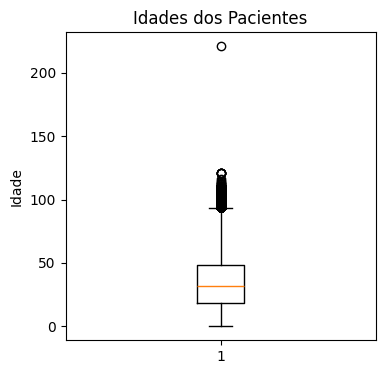

In [12]:
#visualização dos quartis
idades = df['paciente_idade'].dropna()

plt.figure(figsize=(4,4))
plt.boxplot(idades)
plt.title("Idades dos Pacientes")
plt.ylabel("Idade")
plt.show()

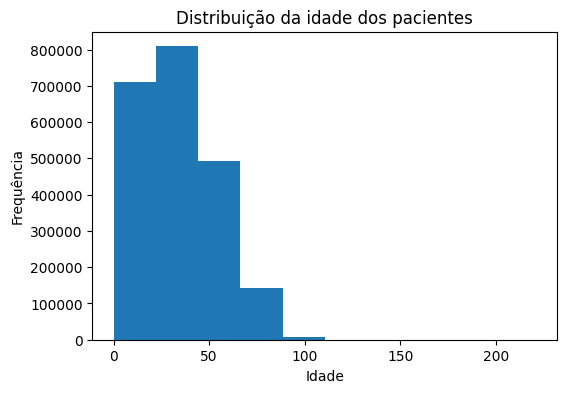

In [13]:
#distribuição das idades
plt.figure(figsize=(6,4))
plt.hist(idades)
plt.title('Distribuição da idade dos pacientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

**ANÁLISE**  
Percebe-se que a vacinação foi mais frequente entre pessoas mais jovens, principalmente entre jovens de 18 anos, e adultos até 50 anos.
Os dados mostram que as vacinas foram aplicadas também entre bebês com menos de 1 ano de idade, mas a integridade dos dados pode ser questionada ao apresentar um registro de um paciente vacinado nascido em 1800, com mais de 220 anos. Essa teoria é reforçada ao analisar a presença de muitos outliers positivos no dataset, com valores muito acima de 100 anos, sendo biologicamente impossível, logo demonstrando que existem muitos registros incorretos.

## Outros gráficos relevantes

### Vacinação com o passar do tempo

In [14]:
df["vacina_dataAplicacao"] = pd.to_datetime(df["vacina_dataAplicacao"])
df["ano_aplicacao"] = df["vacina_dataAplicacao"].dt.year
df["mes_aplicacao"] = df["vacina_dataAplicacao"].dt.month

vacinas_por_mes = df.groupby(['ano_aplicacao', 'mes_aplicacao']).size().reset_index(name='quantidade')
vacinas_por_mes.head(5)

,ano_aplicacao,mes_aplicacao,quantidade
0,2018,7,1
1,2020,8,1
2,2021,1,18474
3,2021,2,47265
4,2021,3,52274


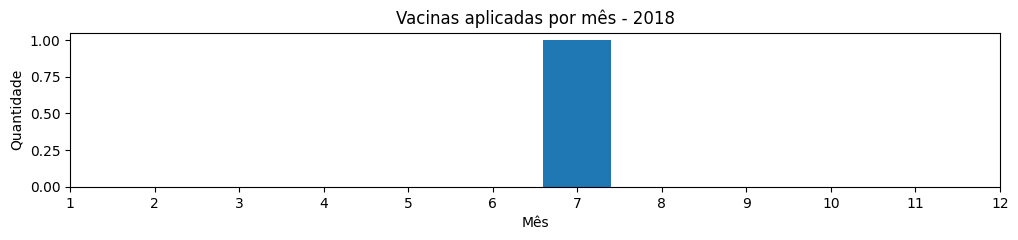

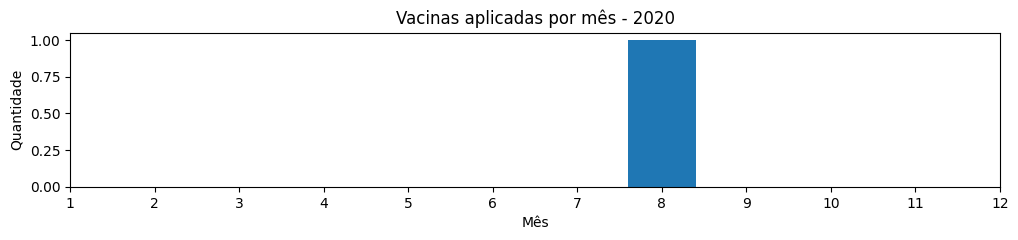

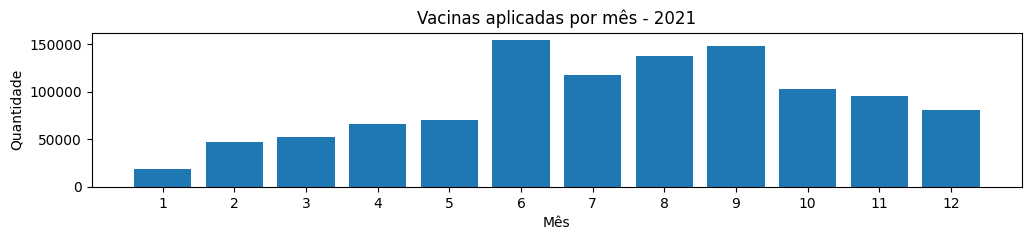

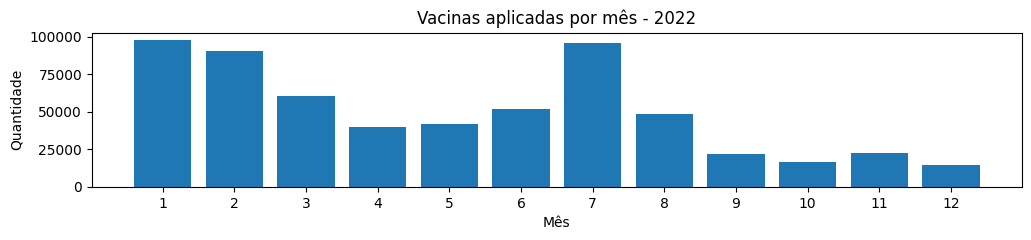

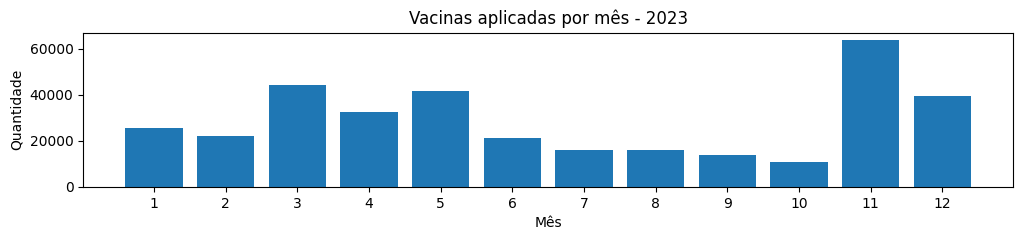

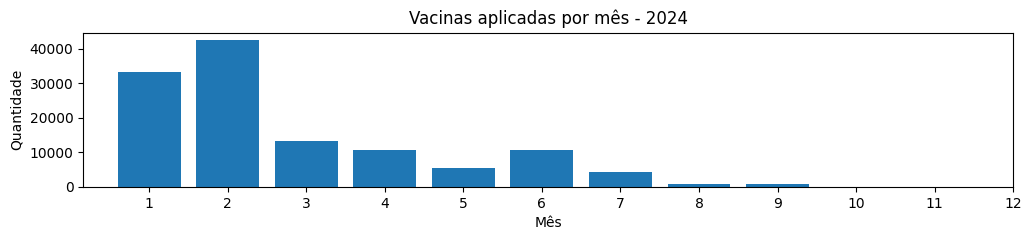

In [15]:
ano = vacinas_por_mes['ano_aplicacao'].unique()
for y in sorted(ano):
    dados = vacinas_por_mes[vacinas_por_mes['ano_aplicacao'] == y]

    plt.figure(figsize=(12,2))
    plt.bar(dados['mes_aplicacao'], dados['quantidade'])
    plt.title(f'Vacinas aplicadas por mês - {y}')
    plt.ylabel('Quantidade')
    plt.xlabel('Mês')
    plt.xticks(range(1, 13))
    plt.show()

**ANÁLISE**  
Os picos de vacinação começaram em 2021, como conhecido pelas notícias, inicialmente somente para grupos de risco e depois para o público geral, e isso pode ser observado no gráfico de 2021. As aplicações se mantiveram constantes com poucos picos até 2023, e então desaceleraram em 2024, refletindo a imunidade que foi sendo construída ao longo do tempo.

### Vacinas por fabricante

In [16]:
fabricante_counts = (df['vacina_fabricante_nome'].value_counts().reset_index())
fabricante_counts.columns = ['fabricante', 'quantidade']

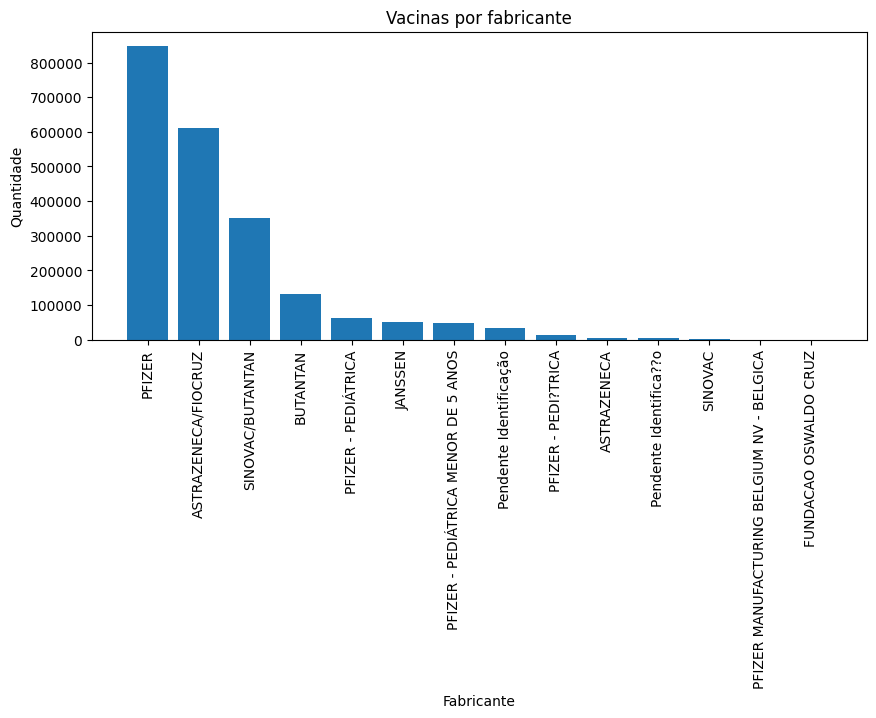

In [17]:
plt.figure(figsize=(10,4))
plt.bar(fabricante_counts['fabricante'], fabricante_counts['quantidade'])
plt.title('Vacinas por fabricante')
plt.ylabel('Quantidade')
plt.xlabel('Fabricante')
plt.xticks(rotation=90)
plt.show()

**ANÁLISE**  
A vacina mais aplicada foi a PFIZER, seguida pela Astrazaneca, Sinovac e Butantan. Essas vacinas não foram disponibilizadas ao mesmo tempo, o que explica a distribuição diversificada.

### Distribuição por sexo

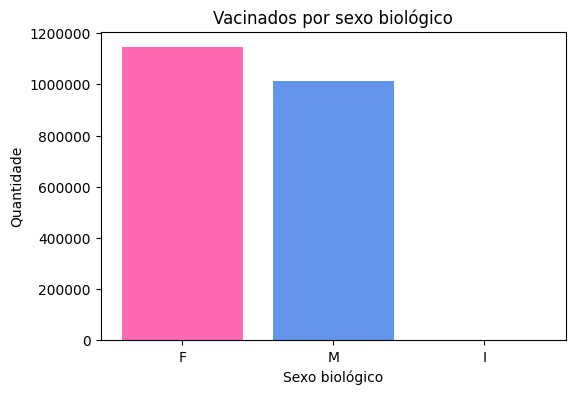

In [18]:
sexo_counts = (df['paciente_enumSexoBiologico'].value_counts().reset_index())
sexo_counts.columns = ['sexo_biologico', 'quantidade']

cores = ['hotpink', '#6495ED']

plt.figure(figsize=(6,4))
plt.bar(sexo_counts['sexo_biologico'], sexo_counts['quantidade'], color=cores)
plt.title('Vacinados por sexo biológico')
plt.ylabel('Quantidade')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Sexo biológico')
plt.show()

**ANÁLISE**  
Apesar da maioria dos vacinados serem do sexo feminino, a distribuição de vacinados está relativamente equilibrada entre os sexos.

### Vacinas por grupo de atendimento

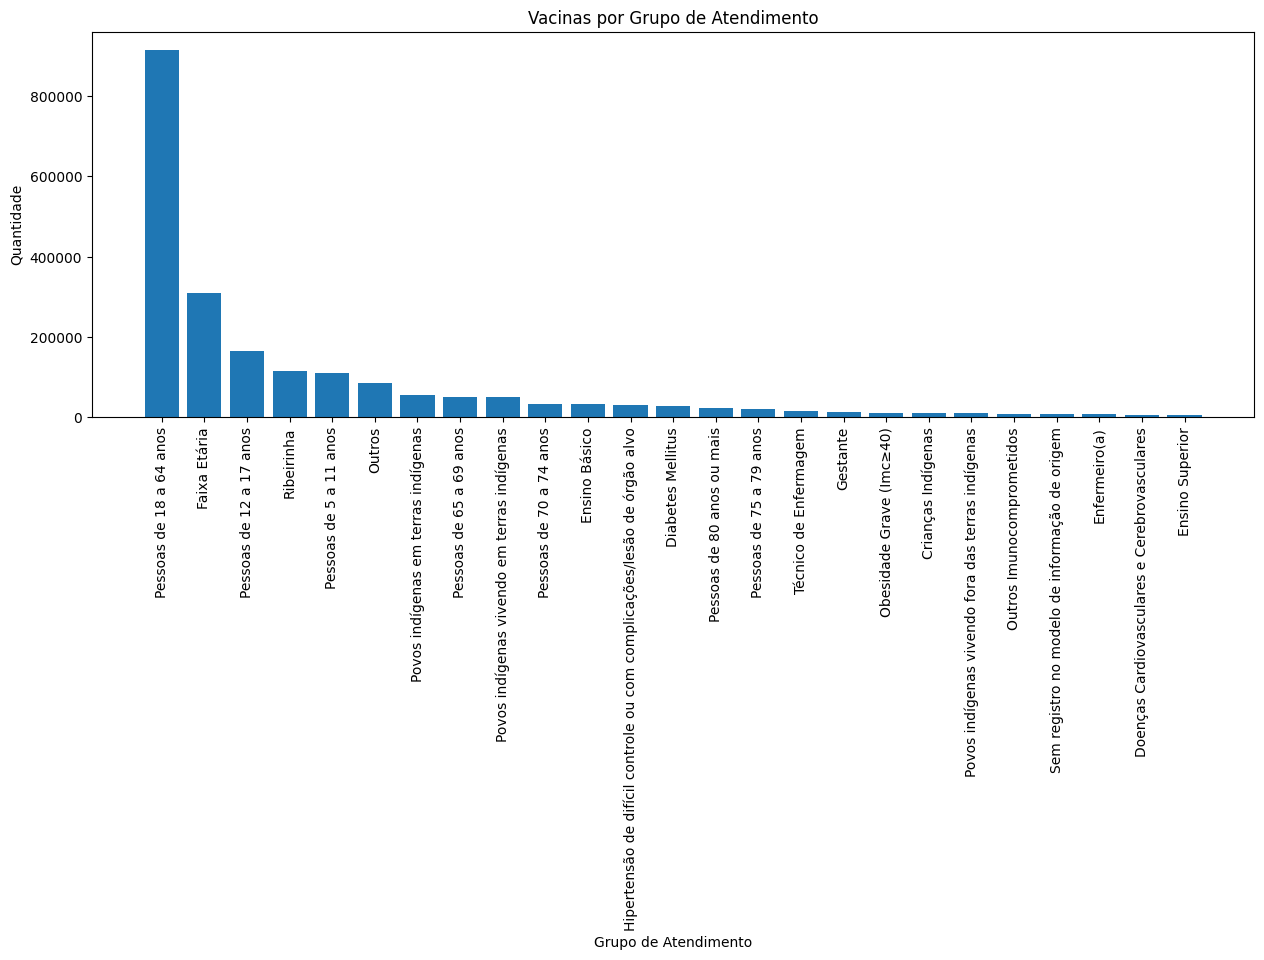

In [19]:
grupo_counts = df['vacina_grupoAtendimento_nome'].value_counts()

#nova série agrupando valores menores que o limite como "Outros"
limite = 5000
grupo_limitado = grupo_counts.copy()
grupo_limitado[grupo_limitado < limite] = 0 
outros_total = grupo_counts[grupo_counts < limite].sum() #atribuindo valor ao grupo limitado

#colunas finais
grupo_final = grupo_limitado[grupo_limitado >= limite]
if outros_total > 0:
    grupo_final['Outros'] = outros_total

#ordena
grupo_final = grupo_final.sort_values(ascending=False)

# Plot
plt.figure(figsize=(15,5))
bars = plt.bar(grupo_final.index, grupo_final.values)
plt.title('Vacinas por Grupo de Atendimento')
plt.xlabel('Grupo de Atendimento')
plt.ylabel('Quantidade')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**ANÁLISE**  
Como o dadaset abrange os anos de 2018 até 2024, é esperado que os registros sejam muito maiores no grupo de atendimento do público geral, "Pessoas de 18 a 64 anos". Entretanto, o grupo de atendimento com segundo maior número de registros é o "Faixa etária", indicando que boa parte da população se vacinou quando somente a sua faixa de idade era prioridade, nos primeiros estágios da campanha, onde haviam chamadas por grupos de idade.

### Continuidade nas doses

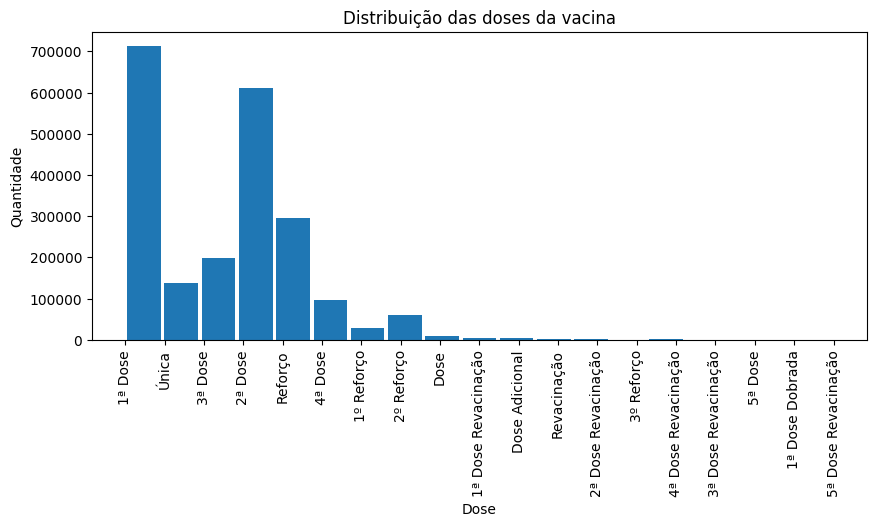

In [39]:
#Distribuição das doses de vacina
doses_vacina = df['vacina_descricao_dose']
n_bins = len(doses_vacina.unique())

plt.figure(figsize=(10,4))
plt.hist(doses_vacina, bins=n_bins, rwidth=0.9)
plt.title('Distribuição das doses da vacina')
plt.ylabel('Quantidade')
plt.xlabel('Dose')
plt.xticks(rotation=90)
plt.show()

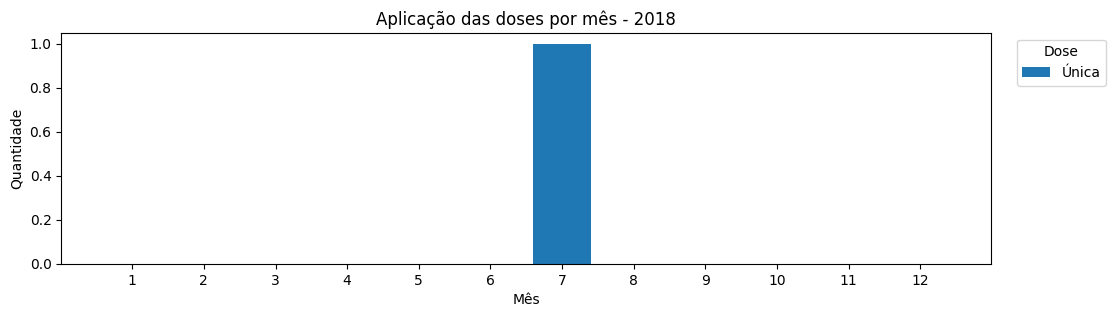

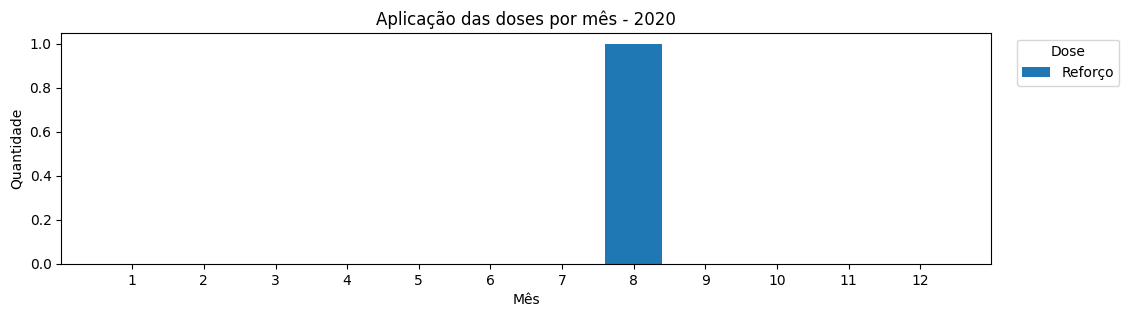

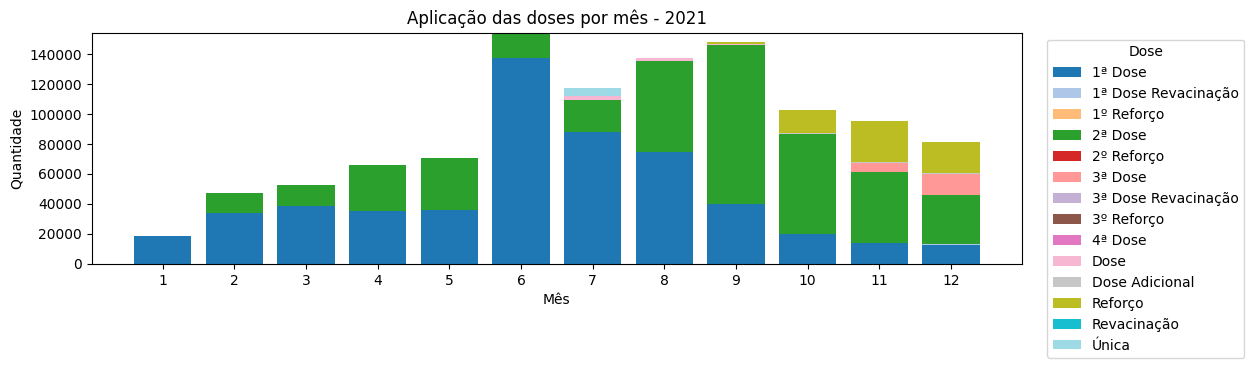

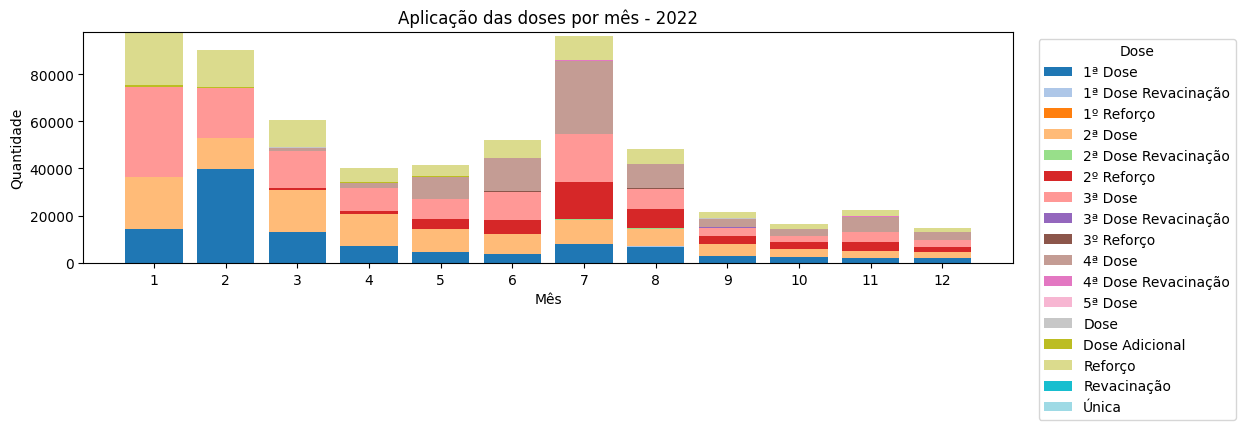

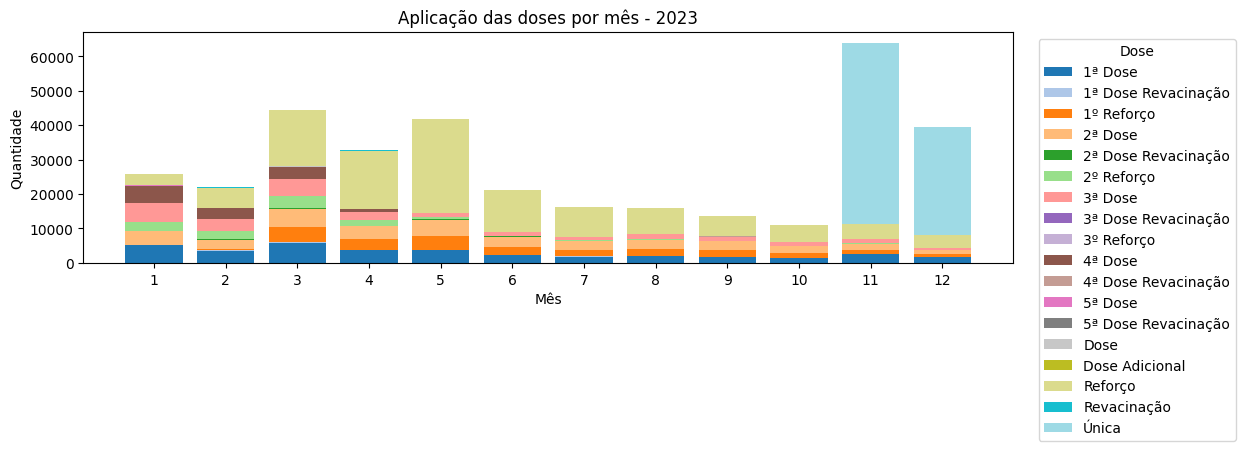

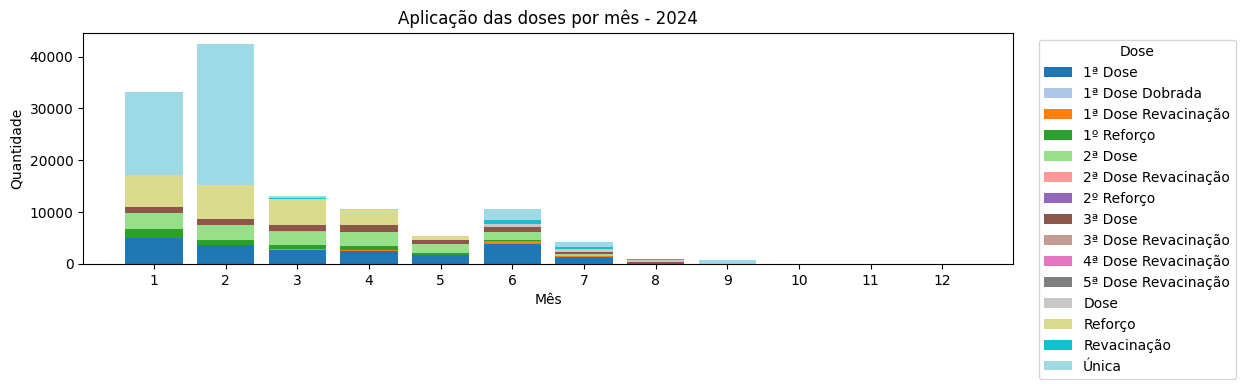

In [42]:
#Aplicação das doses da vacina com o passar do tempo
vacinas = (df.groupby(['ano_aplicacao', 'mes_aplicacao', 'vacina_descricao_dose']).size().reset_index(name='quantidade'))

#para o formato de stacked bars
vacinas_pivot = vacinas.pivot_table(index=['ano_aplicacao', 'mes_aplicacao'], columns='vacina_descricao_dose', values='quantidade', fill_value=0)

anos = vacinas_pivot.index.get_level_values('ano_aplicacao').unique()

for y in sorted(anos):
    dados_ano = vacinas_pivot.loc[y]
    dados_ano = dados_ano.reindex(range(1,13), fill_value=0)
    dados_ano = dados_ano.loc[:, dados_ano.sum() > 0]
    doses = dados_ano.columns
    n_doses = len(doses)

    #cores
    cmap = plt.get_cmap('tab20')
    cores = cmap(np.linspace(0, 1, n_doses))

    #plot
    bottom = None
    plt.figure(figsize=(12,3))

    for i, dose in enumerate(doses):
        if bottom is None:
            plt.bar(dados_ano.index, dados_ano[dose], label=dose, color=cores[i])
            bottom = dados_ano[dose].values
        else:
            plt.bar(dados_ano.index, dados_ano[dose], bottom=bottom, label=dose, color=cores[i])
            bottom += dados_ano[dose].values

    plt.title(f'Aplicação das doses por mês - {y}')
    plt.ylabel('Quantidade')
    plt.xlabel('Mês')
    plt.xticks(range(1,13))
    plt.legend(title="Dose", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.show()

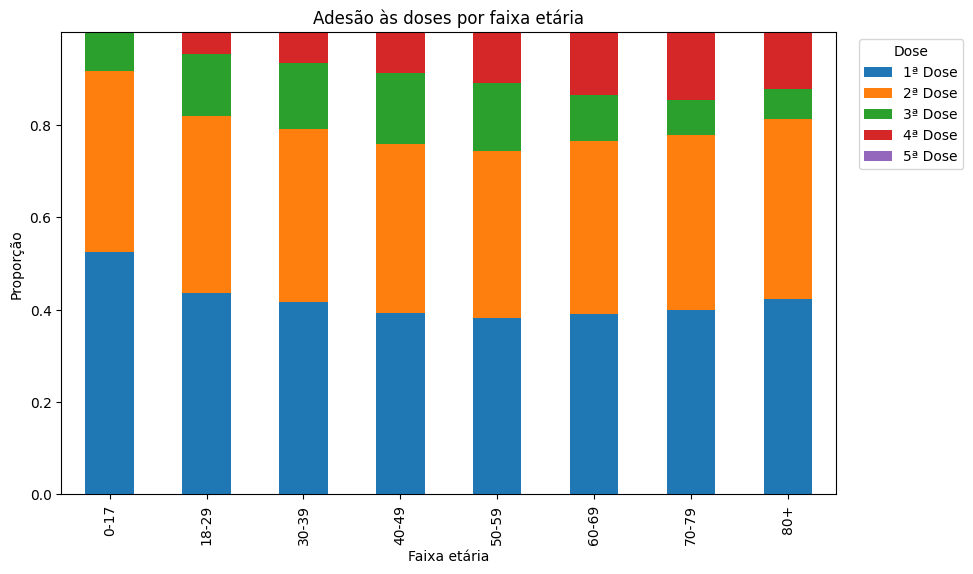

In [46]:
#Adesão das doses conforme a idade
#idades
bins = [0, 17, 29, 39, 49, 59, 69, 79, 120]
labels = ['0-17','18-29','30-39','40-49','50-59','60-69','70-79','80+']
df['faixa_etaria'] = pd.cut(df['paciente_idade'], bins=bins, labels=labels)

#doses
doses_interesse = ['1ª Dose', '2ª Dose', '3ª Dose', '4ª Dose', '5ª Dose']
df_filtrado = df[df['vacina_descricao_dose'].isin(doses_interesse)]

tabela = pd.crosstab(df_filtrado['faixa_etaria'], df_filtrado['vacina_descricao_dose'], normalize='index')

#plot
tabela.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel('Proporção')
plt.xlabel('Faixa etária')
plt.title('Adesão às doses por faixa etária')
plt.legend(title='Dose', bbox_to_anchor=(1.02,1))
plt.show()

**ANÁLISE**  
Em geral, a primeira e segunda dose da vacina são as mais aderidas, e a partir da terceira dose existe uma queda brusca na retenção. Pacientes entre 18 e 59 anos ainda aderem à terceira dose, com destaque para a faixa dos 40 aos 49 anos, e a quarta dose é mais comum entre pacientes de 60 a 79 anos.